In [76]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [77]:
%load_ext kedro.ipython
%reload_kedro ..

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


[06/24/26 19:06:14] INFO     No typed parameter requirements found, returning original   ]8;id=13864612;file://c:\Users\franc\Desktop\mlops-project\.venv\lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=13864613;file://c:\Users\franc\Desktop\mlops-project\.venv\lib\site-packages\kedro\validation\parameter_validator.py#108\108]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=13864618;file://c:\Users\franc\Desktop\mlops-project\.venv\lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=13864619;file://c:\Users\franc\Desktop\mlops-project\.venv\lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[06/24/26 19:06:15] INFO     Kedro project Mortgage Default                                         ]8;id=13864624;file://c:\Users\franc\Desktop\mlops-project\.venv\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=13864625;file://c:\Users\franc\Desktop\mlops-project\.venv\lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=13864630;file://c:\Users\franc\Desktop\mlops-project\.venv\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=13864631;file://c:\Users\franc\Desktop\mlops-project\.venv\lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=13864636;file://c:\Users\franc\Desktop\mlops-project\.venv\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=13864637;file://c:\Users\franc\Desktop\mlops-project\.venv\lib\site-packages\kedro\ipython\__init__.py#154\154]8;;\

In [78]:

df = catalog.load("model_input_validated")
df.shape

                    INFO     Loading data from model_input_validated (ParquetDataset)...       ]8;id=13864642;file://c:\Users\franc\Desktop\mlops-project\.venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=13864643;file://c:\Users\franc\Desktop\mlops-project\.venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

(50000, 33)

In [79]:
df.head()

,credit_score,first_payment_date,first_time_homebuyer_flag,maturity_date,msa,mi_percentage,number_of_units,occupancy_status,original_cltv,original_dti,...,seller_name,servicer_name,super_conforming_flag,pre_relief_refinance_loan_sequence_number,special_eligibility_program,relief_refinance_indicator,property_valuation_method,interest_only_indicator,mi_cancellation_indicator,default
0,609,200503,N,202002,NaN,12,1,P,90,36,...,Other sellers,U.S. BANK N.A.,NaN,NaN,9,NaN,7,N,9,0
1,646,200505,N,203504,17140.0,0,1,P,77,43,...,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,9,0
2,729,200503,N,203502,NaN,0,1,P,61,33,...,Other sellers,"PNC MORTGAGE SERVICES, INC.",NaN,NaN,9,NaN,7,N,9,0
3,748,200503,N,203502,NaN,0,1,P,68,26,...,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,9,0
4,810,200503,N,203502,43780.0,0,1,P,49,26,...,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,9,0


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   credit_score                               50000 non-null  int64  
 1   first_payment_date                         50000 non-null  int64  
 2   first_time_homebuyer_flag                  50000 non-null  object 
 3   maturity_date                              50000 non-null  int64  
 4   msa                                        41916 non-null  float64
 5   mi_percentage                              50000 non-null  int64  
 6   number_of_units                            50000 non-null  int64  
 7   occupancy_status                           50000 non-null  object 
 8   original_cltv                              50000 non-null  int64  
 9   original_dti                               50000 non-null  int64  
 10  original_upb          

In [81]:
df["default"].value_counts(normalize=True, dropna=False).mul(100).round(3)


default
0    94.622
1     5.378
Name: proportion, dtype: float64

In [82]:
performance_columns = [
    "monthly_reporting_period",
    "current_actual_upb",
    "current_loan_delinquency_status",
    "loan_age",
    "remaining_months_to_legal_maturity",
    "defect_settlement_date",
    "modification_flag",
    "zero_balance_code",
    "zero_balance_effective_date",
    "current_interest_rate",
    "current_non_interest_bearing_upb",
    "due_date_last_paid_installment",
    "mi_recoveries",
    "net_sale_proceeds",
    "non_mi_recoveries",
    "total_expenses",
    "legal_costs",
    "maintenance_preservation_costs",
    "taxes_insurance",
    "miscellaneous_expenses",
    "actual_loss_calculation",
    "cumulative_modification_cost",
    "interest_rate_step_indicator",
    "payment_deferral_flag",
    "estimated_ltv",
    "zero_balance_removal_upb",
    "delinquent_accrued_interest",
    "delinquency_due_to_disaster",
    "borrower_assistance_status_code",
    "current_month_modification_cost",
    "interest_bearing_upb",
]

[col for col in performance_columns if col in df.columns]

[]

In [83]:
sentinel_rules = {
    "credit_score": [9999],
    "mi_percentage": [999],
    "number_of_units": [99],
    "first_time_homebuyer_flag": [9],
    "occupancy_status": [9],
    "channel": [9],
    "property_type": [99],
    "loan_purpose": [9],
    "original_cltv": [999],
    "original_dti": [999],
    "original_ltv": [999],
    "number_of_borrowers": [99],
    "special_eligibility_program": [9],
    "property_valuation_method": [7],
    "mi_cancellation_indicator": [7, 9],
}

rows = []

for col, values in sentinel_rules.items():
    if col not in df.columns:
        continue

    s = df[col].astype("string").str.strip()
    unique_values = sorted(set(str(v) for v in values))

    for value in unique_values:
        count = int((s == value).sum())

        if count > 0:
            rows.append(
                {
                    "column": col,
                    "sentinel_value": value,
                    "count": count,
                    "rate_%": round(count / len(df) * 100, 3),
                }
            )

sentinel_summary = pd.DataFrame(rows).sort_values(
    "count",
    ascending=False,
)

sentinel_summary

,column,sentinel_value,count,rate_%
8,special_eligibility_program,9,50000,100.000
10,mi_cancellation_indicator,9,50000,100.000
9,property_valuation_method,7,50000,100.000
5,original_dti,999,1532,3.064
0,credit_score,9999,41,0.082
7,number_of_borrowers,99,11,0.022
2,first_time_homebuyer_flag,9,8,0.016
6,original_ltv,999,2,0.004
4,original_cltv,999,2,0.004
1,number_of_units,99,1,0.002


In [84]:
missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate_%": df.isna().mean().mul(100).round(3),
}).sort_values("missing_count", ascending=False)

missing_report[missing_report["missing_count"] > 0]

,missing_count,missing_rate_%
relief_refinance_indicator,50000,100.000
pre_relief_refinance_loan_sequence_number,50000,100.000
super_conforming_flag,50000,100.000
msa,8084,16.168


In [85]:
df["loan_sequence_number"].duplicated().sum()

np.int64(0)

In [86]:
cleaned = df.copy()

cleaning_stats = {
    "rows_before": int(len(cleaned)),
    "columns_before": int(cleaned.shape[1]),
}

# Numeric sentinel values -> missing
numeric_sentinel_map = {
    "credit_score": [9999],
    "mi_percentage": [999],
    "number_of_units": [99],
    "original_cltv": [999],
    "original_dti": [999],
    "original_ltv": [999],
    "number_of_borrowers": [99],
}

for col, sentinels in numeric_sentinel_map.items():
    if col in cleaned.columns:
        cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

        mask = cleaned[col].isin(sentinels)
        cleaning_stats[f"{col}_sentinel_count"] = int(mask.sum())

        cleaned.loc[mask, col] = pd.NA

# Categorical sentinel values -> UNKNOWN
categorical_unknown_map = {
    "first_time_homebuyer_flag": ["9"],
    "occupancy_status": ["9"],
    "channel": ["9"],
    "property_type": ["99"],
    "loan_purpose": ["9"],
}

for col, sentinels in categorical_unknown_map.items():
    if col in cleaned.columns:
        cleaned[col] = cleaned[col].astype("string").str.strip().str.upper()

        mask = cleaned[col].isin(sentinels)
        cleaning_stats[f"{col}_unknown_count"] = int(mask.sum())

        cleaned.loc[mask, col] = "UNKNOWN"

In [87]:
for col in ["first_payment_date", "maturity_date"]:
    if col in cleaned.columns:
        cleaned[col] = pd.to_datetime(
            cleaned[col].astype("string").str.strip(),
            format="%Y%m",
            errors="coerce",
        )

        cleaning_stats[f"{col}_parse_failed_count"] = int(cleaned[col].isna().sum())

In [88]:
columns_to_drop = [
    "super_conforming_flag",
    "pre_relief_refinance_loan_sequence_number",
    "relief_refinance_indicator",
    "property_valuation_method",
    "mi_cancellation_indicator",
    "special_eligibility_program",
]

existing_drop_cols = [col for col in columns_to_drop if col in cleaned.columns]

cleaning_stats["dropped_columns"] = existing_drop_cols

cleaned = cleaned.drop(columns=existing_drop_cols)

In [89]:
cleaning_stats["rows_after"] = int(len(cleaned))
cleaning_stats["columns_after"] = int(cleaned.shape[1])
cleaning_stats["rows_removed"] = int(
    cleaning_stats["rows_before"] - cleaning_stats["rows_after"]
)

cleaning_stats


{
    'rows_before': 50000,
    'columns_before': 33,
    'credit_score_sentinel_count': 41,
    'mi_percentage_sentinel_count': 0,
    'number_of_units_sentinel_count': 1,
    'original_cltv_sentinel_count': 2,
    'original_dti_sentinel_count': 1532,
    'original_ltv_sentinel_count': 2,
    'number_of_borrowers_sentinel_count': 11,
    'first_time_homebuyer_flag_unknown_count': 8,
    'occupancy_status_unknown_count': 0,
    'channel_unknown_count': 0,
    'property_type_unknown_count': 1,
    'loan_purpose_unknown_count': 0,
    'first_payment_date_parse_failed_count': 0,
    'maturity_date_parse_failed_count': 0,
    'dropped_columns': [
        'super_conforming_flag',
        'pre_relief_refinance_loan_sequence_number',
        'relief_refinance_indicator',
        'property_valuation_method',
        'mi_cancellation_indicator',
        'special_eligibility_program'
    ],
    'rows_after': 50000,
    'columns_after': 27,
    'rows_removed': 0
}

In [90]:
cleaned.head()

,credit_score,first_payment_date,first_time_homebuyer_flag,maturity_date,msa,mi_percentage,number_of_units,occupancy_status,original_cltv,original_dti,...,property_type,postal_code,loan_sequence_number,loan_purpose,original_loan_term,number_of_borrowers,seller_name,servicer_name,interest_only_indicator,default
0,609.0,2005-03-01,N,2020-02-01,NaN,12.0,1.0,P,90.0,36.0,...,SF,30400,F05Q10000006,C,180,1.0,Other sellers,U.S. BANK N.A.,N,0
1,646.0,2005-05-01,N,2035-04-01,17140.0,0.0,1.0,P,77.0,43.0,...,SF,41000,F05Q10000011,N,360,2.0,Other sellers,Other servicers,N,0
2,729.0,2005-03-01,N,2035-02-01,NaN,0.0,1.0,P,61.0,33.0,...,SF,45000,F05Q10000061,N,360,2.0,Other sellers,"PNC MORTGAGE SERVICES, INC.",N,0
3,748.0,2005-03-01,N,2035-02-01,NaN,0.0,1.0,P,68.0,26.0,...,SF,61000,F05Q10000093,P,360,2.0,Other sellers,Other servicers,N,0
4,810.0,2005-03-01,N,2035-02-01,43780.0,0.0,1.0,P,49.0,26.0,...,SF,46600,F05Q10000128,P,360,2.0,Other sellers,Other servicers,N,0


In [91]:
missing_after_cleaning = pd.DataFrame({
    "missing_count": cleaned.isna().sum(),
    "missing_rate_%": cleaned.isna().mean().mul(100).round(3),
}).sort_values("missing_count", ascending=False)

missing_after_cleaning[missing_after_cleaning["missing_count"] > 0]

,missing_count,missing_rate_%
msa,8084,16.168
original_dti,1532,3.064
credit_score,41,0.082
number_of_borrowers,11,0.022
original_cltv,2,0.004
original_ltv,2,0.004
number_of_units,1,0.002


In [92]:
range_checks = {
    "credit_score_valid": cleaned["credit_score"].dropna().between(300, 850).all(),
    "original_dti_valid": cleaned["original_dti"].dropna().between(1, 65).all(),
    "original_ltv_valid": cleaned["original_ltv"].dropna().between(6, 105).all(),
    "original_cltv_valid": cleaned["original_cltv"].dropna().between(6, 200).all(),
    "mi_percentage_valid": cleaned["mi_percentage"].dropna().between(0, 55).all(),
    "number_of_units_valid": cleaned["number_of_units"].dropna().isin([1, 2, 3, 4]).all(),
    "number_of_borrowers_valid": cleaned["number_of_borrowers"].dropna().isin([1, 2]).all(),
    "default_valid": cleaned["default"].dropna().isin([0, 1]).all(),
}

range_checks


{
    'credit_score_valid': np.True_,
    'original_dti_valid': np.True_,
    'original_ltv_valid': np.True_,
    'original_cltv_valid': np.True_,
    'mi_percentage_valid': np.True_,
    'number_of_units_valid': np.True_,
    'number_of_borrowers_valid': np.True_,
    'default_valid': np.True_
}

In [93]:
cleaned.loc[
    cleaned["credit_score"].notna()
    & ~cleaned["credit_score"].between(300, 850),
    ["loan_sequence_number", "credit_score"]
]

,loan_sequence_number,credit_score


In [94]:
cleaned.loc[
    cleaned["original_dti"].notna()
    & ~cleaned["original_dti"].between(1, 65),
    ["loan_sequence_number", "original_dti"]
]

,loan_sequence_number,original_dti


In [95]:
cleaned.loc[
    cleaned["original_ltv"].notna()
    & ~cleaned["original_ltv"].between(6, 105),
    ["loan_sequence_number", "original_ltv"]
]

,loan_sequence_number,original_ltv


In [96]:
categorical_cols = [
    "first_time_homebuyer_flag",
    "occupancy_status",
    "channel",
    "prepayment_penalty_flag",
    "amortization_type",
    "property_state",
    "property_type",
    "loan_purpose",
    "interest_only_indicator",
]

for col in categorical_cols:
    if col in cleaned.columns:
        print(f"\n--- {col} ---")
        print(cleaned[col].value_counts(dropna=False).head(20))


--- first_time_homebuyer_flag ---
first_time_homebuyer_flag
N          45795
Y           4197
UNKNOWN        8
Name: count, dtype: Int64

--- occupancy_status ---
occupancy_status
P    46017
S     2389
I     1594
Name: count, dtype: Int64

--- channel ---
channel
T    26358
R    23513
C       93
B       36
Name: count, dtype: Int64

--- prepayment_penalty_flag ---
prepayment_penalty_flag
N    49895
Y      105
Name: count, dtype: int64

--- amortization_type ---
amortization_type
FRM    50000
Name: count, dtype: int64

--- property_state ---
property_state
CA    4732
FL    3639
IL    2597
TX    2475
MI    2009
PA    1936
NY    1933
OH    1870
AZ    1746
NJ    1499
WA    1494
VA    1493
MD    1491
GA    1416
NC    1387
WI    1384
MN    1275
IN    1189
MO    1187
MA    1154
Name: count, dtype: int64

--- property_type ---
property_type
SF         39644
PU          6229
CO          3325
MH           622
CP           179
UNKNOWN        1
Name: count, dtype: Int64

--- loan_purpose ---
loan

In [97]:
cleaned["loan_sequence_number"].duplicated().sum()

np.int64(0)

In [98]:
cleaned["default"].value_counts(normalize=True, dropna=False).mul(100).round(3)


default
0    94.622
1     5.378
Name: proportion, dtype: float64

In [99]:
(cleaned["maturity_date"] > cleaned["first_payment_date"]).value_counts(dropna=False)


True    50000
Name: count, dtype: int64

In [100]:
months_between = (
    (cleaned["maturity_date"].dt.year - cleaned["first_payment_date"].dt.year) * 12
    + (cleaned["maturity_date"].dt.month - cleaned["first_payment_date"].dt.month)
    + 1
)

term_difference = months_between - cleaned["original_loan_term"]

term_difference.value_counts().sort_index().head(20)


0    50000
Name: count, dtype: int64

In [101]:
cleaning_stats["missing_values_after_cleaning"] = (
    cleaned.isna().sum().astype(int).to_dict()
)

cleaning_stats["range_checks"] = {
    key: bool(value)
    for key, value in range_checks.items()
}

cleaning_stats["duplicate_loan_sequence_number_count"] = int(
    cleaned["loan_sequence_number"].duplicated().sum()
)

cleaning_stats["target_distribution"] = (
    cleaned["default"].value_counts(dropna=False).astype(int).to_dict()
)

In [102]:
cleaning_stats


{
    'rows_before': 50000,
    'columns_before': 33,
    'credit_score_sentinel_count': 41,
    'mi_percentage_sentinel_count': 0,
    'number_of_units_sentinel_count': 1,
    'original_cltv_sentinel_count': 2,
    'original_dti_sentinel_count': 1532,
    'original_ltv_sentinel_count': 2,
    'number_of_borrowers_sentinel_count': 11,
    'first_time_homebuyer_flag_unknown_count': 8,
    'occupancy_status_unknown_count': 0,
    'channel_unknown_count': 0,
    'property_type_unknown_count': 1,
    'loan_purpose_unknown_count': 0,
    'first_payment_date_parse_failed_count': 0,
    'maturity_date_parse_failed_count': 0,
    'dropped_columns': [
        'super_conforming_flag',
        'pre_relief_refinance_loan_sequence_number',
        'relief_refinance_indicator',
        'property_valuation_method',
        'mi_cancellation_indicator',
        'special_eligibility_program'
    ],
    'rows_after': 50000,
    'columns_after': 27,
    'rows_removed': 0,
    'missing_values_after_cleani

In [103]:
allowed_category_values = {
    "first_time_homebuyer_flag": {"Y", "N", "UNKNOWN"},
    "occupancy_status": {"P", "I", "S", "UNKNOWN"},
    "channel": {"R", "B", "C", "T", "UNKNOWN"},
    "prepayment_penalty_flag": {"Y", "N"},
    "amortization_type": {"FRM", "ARM"},
    "property_type": {"CO", "PU", "MH", "SF", "CP", "UNKNOWN"},
    "loan_purpose": {"P", "C", "N", "R", "UNKNOWN"},
    "interest_only_indicator": {"Y", "N"},
}

categorical_check_results = {}

for col, allowed_values in allowed_category_values.items():
    if col in cleaned.columns:
        observed = set(cleaned[col].dropna().astype(str).str.strip().str.upper())
        unexpected = sorted(observed - allowed_values)
        categorical_check_results[col] = {
            "observed_values": sorted(observed),
            "unexpected_values": unexpected,
            "valid": len(unexpected) == 0,
        }

categorical_check_results



{
    'first_time_homebuyer_flag': {
        'observed_values': ['N', 'UNKNOWN', 'Y'],
        'unexpected_values': [],
        'valid': True
    },
    'occupancy_status': {'observed_values': ['I', 'P', 'S'], 'unexpected_values': [], 'valid': True},
    'channel': {'observed_values': ['B', 'C', 'R', 'T'], 'unexpected_values': [], 'valid': True},
    'prepayment_penalty_flag': {
        'observed_values': ['N', 'Y'],
        'unexpected_values': [],
        'valid': True
    },
    'amortization_type': {'observed_values': ['FRM'], 'unexpected_values': [], 'valid': True},
    'property_type': {
        'observed_values': ['CO', 'CP', 'MH', 'PU', 'SF', 'UNKNOWN'],
        'unexpected_values': [],
        'valid': True
    },
    'loan_purpose': {'observed_values': ['C', 'N', 'P'], 'unexpected_values': [], 'valid': True},
    'interest_only_indicator': {'observed_values': ['N'], 'unexpected_values': [], 'valid': True}
}

In [104]:
cleaning_stats["categorical_check_results"] = categorical_check_results

In [105]:
date_summary = cleaned[["first_payment_date", "maturity_date"]].agg(["min", "median", "max"])

date_summary

,first_payment_date,maturity_date
min,2005-02-01,2010-04-01
median,2005-09-01,2035-06-01
max,2011-10-01,2045-09-01


In [106]:
first_payment_month_counts = (
    cleaned["first_payment_date"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

first_payment_month_counts.head(), first_payment_month_counts.tail()


(
    first_payment_date
2005-02      72
2005-03    3103
2005-04    3873
2005-05    5321
2005-06    3753
Freq: M, Name: count, dtype: int64,
    first_payment_date
2009-05    1
2009-09    1
2010-05    1
2010-09    2
2011-10    1
Freq: M, Name: count, dtype: int64
)

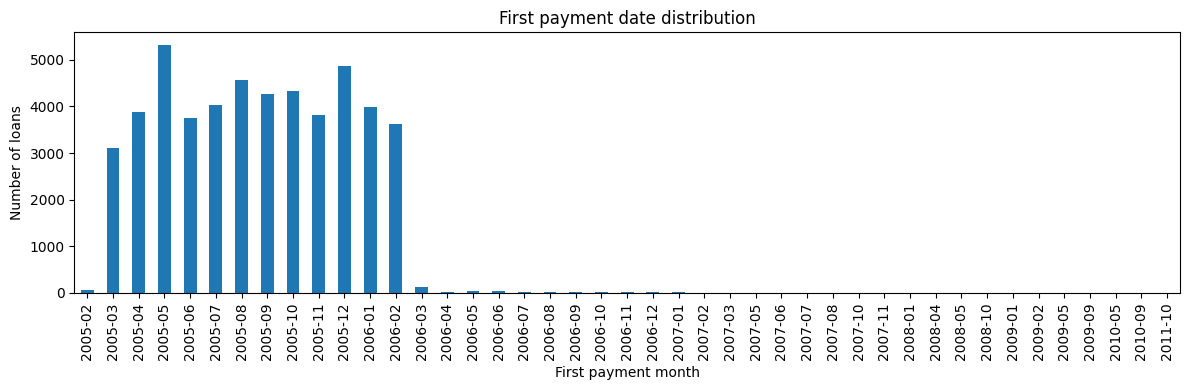

In [107]:
first_payment_month_counts.plot(kind="bar", figsize=(12, 4), title="First payment date distribution")
plt.xlabel("First payment month")
plt.ylabel("Number of loans")
plt.tight_layout()
plt.show()

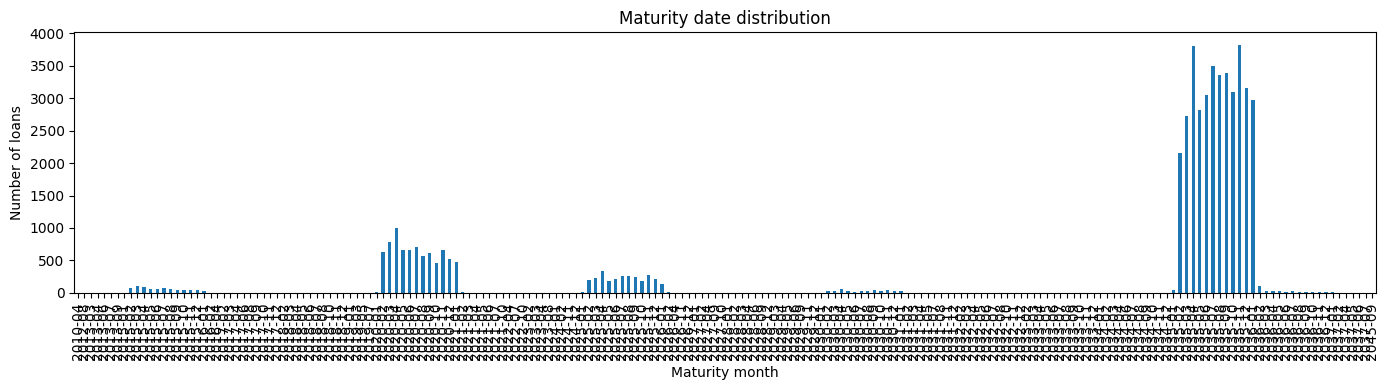

In [108]:
maturity_month_counts = (
    cleaned["maturity_date"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

maturity_month_counts.head(), maturity_month_counts.tail()

maturity_month_counts.plot(kind="bar", figsize=(14, 4), title="Maturity date distribution")
plt.xlabel("Maturity month")
plt.ylabel("Number of loans")
plt.tight_layout()
plt.show()

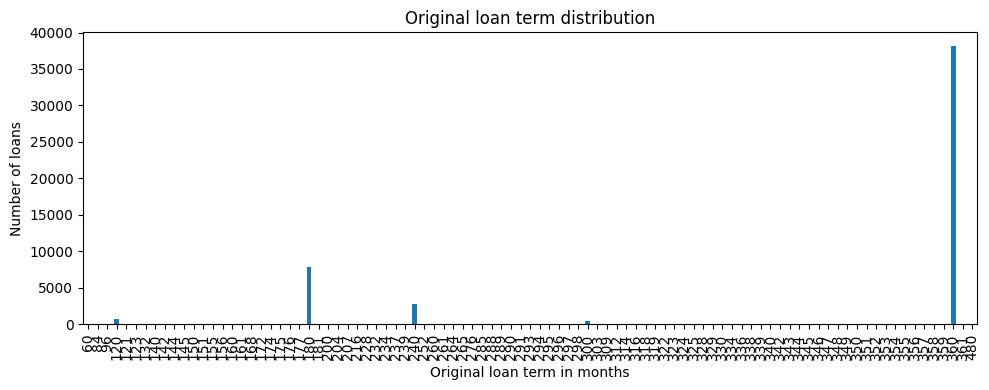

In [109]:
cleaned["original_loan_term"].value_counts().sort_index()
cleaned["original_loan_term"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10, 4),
    title="Original loan term distribution",
)

plt.xlabel("Original loan term in months")
plt.ylabel("Number of loans")
plt.tight_layout()
plt.show()

In [110]:
months_between = (
    (cleaned["maturity_date"].dt.year - cleaned["first_payment_date"].dt.year) * 12
    + (cleaned["maturity_date"].dt.month - cleaned["first_payment_date"].dt.month)
    + 1
)

date_consistency = pd.DataFrame({
    "first_payment_date": cleaned["first_payment_date"],
    "maturity_date": cleaned["maturity_date"],
    "original_loan_term": cleaned["original_loan_term"],
    "months_between_dates": months_between,
    "term_difference": months_between - cleaned["original_loan_term"],
})

date_consistency["term_difference"].value_counts().sort_index()


term_difference
0    50000
Name: count, dtype: int64

In [111]:
cleaning_stats["date_checks"] = {
    "first_payment_date_min": str(cleaned["first_payment_date"].min().date()),
    "first_payment_date_max": str(cleaned["first_payment_date"].max().date()),
    "maturity_date_min": str(cleaned["maturity_date"].min().date()),
    "maturity_date_max": str(cleaned["maturity_date"].max().date()),
    "maturity_after_first_payment_all": bool(
        (cleaned["maturity_date"] > cleaned["first_payment_date"]).all()
    ),
    "term_difference_counts": (
        date_consistency["term_difference"].value_counts().sort_index().astype(int).to_dict()
    ),
}

In [112]:
loan_id_pattern = r"^[FA]\d{2}Q[1-4]\d{7}$"

loan_id_valid = cleaned["loan_sequence_number"].astype(str).str.match(loan_id_pattern)

loan_id_valid.value_counts(dropna=False)


loan_sequence_number
True    50000
Name: count, dtype: int64

In [113]:
cleaning_stats["loan_sequence_number_invalid_count"] = int((~loan_id_valid).sum())

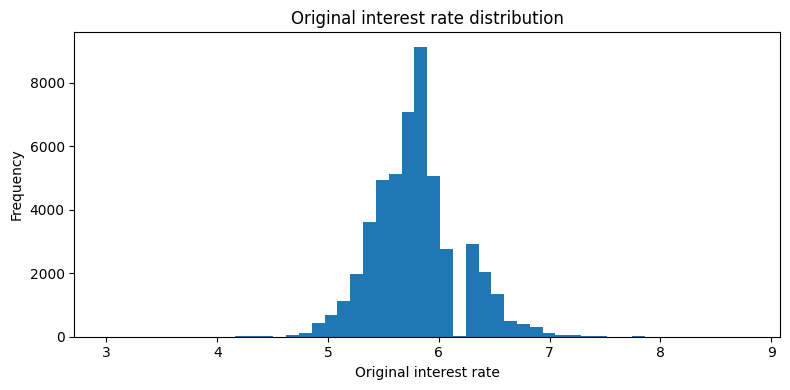

In [114]:
interest_rate_valid = cleaned["original_interest_rate"].between(0, 30)

interest_rate_valid.value_counts(dropna=False)

cleaned["original_interest_rate"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 4),
    title="Original interest rate distribution",
)

plt.xlabel("Original interest rate")
plt.tight_layout()
plt.show()

Check if cleaning pipeline was a success

In [115]:
cleaned_path = Path("../data/03_primary/model_input_cleaned.parquet")

cleaned_df = pd.read_parquet(cleaned_path)

cleaned_df.shape

(50000, 27)

In [116]:
cleaned_df.columns.tolist()


[
    'credit_score',
    'first_payment_date',
    'first_time_homebuyer_flag',
    'maturity_date',
    'msa',
    'mi_percentage',
    'number_of_units',
    'occupancy_status',
    'original_cltv',
    'original_dti',
    'original_upb',
    'original_ltv',
    'original_interest_rate',
    'channel',
    'prepayment_penalty_flag',
    'amortization_type',
    'property_state',
    'property_type',
    'postal_code',
    'loan_sequence_number',
    'loan_purpose',
    'original_loan_term',
    'number_of_borrowers',
    'seller_name',
    'servicer_name',
    'interest_only_indicator',
    'default'
]

In [117]:
dropped_columns = [
    "super_conforming_flag",
    "pre_relief_refinance_loan_sequence_number",
    "relief_refinance_indicator",
    "property_valuation_method",
    "mi_cancellation_indicator",
    "special_eligibility_program",
]

[col for col in dropped_columns if col in cleaned_df.columns]

[]

In [118]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   credit_score               49959 non-null  float64       
 1   first_payment_date         50000 non-null  datetime64[ns]
 2   first_time_homebuyer_flag  50000 non-null  string        
 3   maturity_date              50000 non-null  datetime64[ns]
 4   msa                        41916 non-null  Int64         
 5   mi_percentage              50000 non-null  float64       
 6   number_of_units            49999 non-null  float64       
 7   occupancy_status           50000 non-null  string        
 8   original_cltv              49998 non-null  float64       
 9   original_dti               48468 non-null  float64       
 10  original_upb               50000 non-null  int64         
 11  original_ltv               49998 non-null  float64       
 12  orig

In [119]:
missing_cleaned = pd.DataFrame({
    "missing_count": cleaned_df.isna().sum(),
    "missing_rate_%": cleaned_df.isna().mean().mul(100).round(3),
}).sort_values("missing_count", ascending=False)

missing_cleaned[missing_cleaned["missing_count"] > 0]

,missing_count,missing_rate_%
msa,8084,16.168
original_dti,1532,3.064
credit_score,41,0.082
number_of_borrowers,11,0.022
original_cltv,2,0.004
original_ltv,2,0.004
number_of_units,1,0.002


In [120]:
checks = {
    "shape_is_expected": cleaned_df.shape == (50000, 27),
    "no_duplicate_loan_ids": cleaned_df["loan_sequence_number"].duplicated().sum() == 0,
    "target_is_binary": cleaned_df["default"].isin([0, 1]).all(),
    "credit_score_valid": cleaned_df["credit_score"].dropna().between(300, 850).all(),
    "original_dti_valid": cleaned_df["original_dti"].dropna().between(1, 65).all(),
    "original_ltv_valid": cleaned_df["original_ltv"].dropna().between(6, 105).all(),
    "original_cltv_valid": cleaned_df["original_cltv"].dropna().between(6, 200).all(),
    "mi_percentage_valid": cleaned_df["mi_percentage"].dropna().between(0, 55).all(),
    "number_of_units_valid": cleaned_df["number_of_units"].dropna().isin([1, 2, 3, 4]).all(),
    "number_of_borrowers_valid": cleaned_df["number_of_borrowers"].dropna().isin([1, 2]).all(),
    "maturity_after_first_payment": (cleaned_df["maturity_date"] > cleaned_df["first_payment_date"]).all(),
}

checks


{
    'shape_is_expected': True,
    'no_duplicate_loan_ids': np.True_,
    'target_is_binary': np.True_,
    'credit_score_valid': np.True_,
    'original_dti_valid': np.True_,
    'original_ltv_valid': np.True_,
    'original_cltv_valid': np.True_,
    'mi_percentage_valid': np.True_,
    'number_of_units_valid': np.True_,
    'number_of_borrowers_valid': np.True_,
    'maturity_after_first_payment': np.True_
}

In [121]:
months_between = (
    (cleaned_df["maturity_date"].dt.year - cleaned_df["first_payment_date"].dt.year) * 12
    + (cleaned_df["maturity_date"].dt.month - cleaned_df["first_payment_date"].dt.month)
    + 1
)

term_difference = months_between - cleaned_df["original_loan_term"]

term_difference.value_counts().sort_index()


0    50000
Name: count, dtype: int64

In [122]:
cleaned_df["default"].value_counts(normalize=True).mul(100).round(3)


default
0    94.622
1     5.378
Name: proportion, dtype: float64